# PRAGMA Phase 6 - Prove learnability on tiny data

Runs the single-device debug training loop (`pragma.training.run_debug_training`, section 17 Phase 6) on a small slice of the Phase 0/1 synthetic corpus and checks the exit gate directly: **the model overfits the tiny corpus**, **MLM loss decreases for all three masking strategies**, and **destroyed context degrades predictions** (checked via gradient connectivity, not a magnitude threshold — see the methodology note below).

This machine's GPU (GTX 1650 Ti, 4GB) has a driver too old for current PyTorch CUDA wheels (max CUDA 11.0 reported; modern wheels need 12.x), so this notebook runs on CPU throughout. That's fine for Phase 6's scope — it's explicitly a tiny-corpus correctness smoke test, not a throughput run. `CFG.DEBUG` below controls exactly how tiny: when `True`, only a small fraction of the full corpus and a small model/batch size are used, so the whole notebook runs in well under a minute on CPU.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import torch

from pragma.config import MaskingConfig, ProcessorConfig
from pragma.data.batch import PragmaCollator
from pragma.data.records import PointInTimeRecordBuilder, SplitConfig, drop_zero_event_records
from pragma.data.synthetic import SyntheticDataConfig, generate_synthetic_corpus
from pragma.masking import MaskingPlanner
from pragma.modeling import PragmaConfig
from pragma.processing import PragmaProcessor
from pragma.schema import SchemaRegistry
from pragma.training import (
    DebugTrainingConfig,
    context_dependency_grad,
    run_debug_training,
    shuffle_context_tokens,
)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print(f"torch {torch.__version__}, cuda available: {torch.cuda.is_available()}")

2026/09/08 17:48:32 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\levyr\Desktop\random-projects\pragma\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


torch 2.14.0+cpu, cuda available: False


## `CFG.DEBUG`: a small fraction of data, a small model, a small batch

`batch_size` is deliberately tiny regardless of device — Phase 6 is a correctness check, not a throughput benchmark, and a small batch keeps this notebook cheap to re-run on modest hardware.

In [2]:
@dataclass(frozen=True)
class CFG:
    DEBUG: bool = True

    # Fraction/cap of the Phase 0/1 synthetic corpus to actually use.
    n_entities: int = 12 if DEBUG else 300
    max_events_per_entity: int = 8 if DEBUG else 200

    # Model size.
    hidden_size: int = 24 if DEBUG else 192
    num_heads: int = 2 if DEBUG else 3
    intermediate_size: int = 48 if DEBUG else 768
    event_layers: int = 2 if DEBUG else 5
    history_layers: int = 1 if DEBUG else 2

    # Training.
    batch_size: int = 4  # deliberately small on every device (see markdown above)
    n_epochs: int = 40 if DEBUG else 10
    learning_rate: float = 3e-3 if DEBUG else 3e-4
    seed: int = 0


cfg = CFG()
cfg

CFG(DEBUG=True, n_entities=12, max_events_per_entity=8, hidden_size=24, num_heads=2, intermediate_size=48, event_layers=2, history_layers=1, batch_size=4, n_epochs=40, learning_rate=0.003, seed=0)

## Build a tiny corpus and fit a processor scaled to match

In [3]:
events_df, profile_df, _ = generate_synthetic_corpus(
    SyntheticDataConfig(
        n_entities=cfg.n_entities,
        seed=42,
        max_events_per_entity=cfg.max_events_per_entity,
        n_zero_event_entities=0,
        n_single_event_entities=1,
        n_long_history_entities=0,
        n_same_timestamp_entities=0,
    )
)
registry = SchemaRegistry.default()
records = PointInTimeRecordBuilder(registry, SplitConfig()).build(events_df, profile_df)
records, n_dropped = drop_zero_event_records(records)  # ADR 0014
print(f"dropped {n_dropped} zero-event records before fitting/tokenizing")

processor = PragmaProcessor(registry, ProcessorConfig(n_numeric_buckets=6, bpe_vocab_size=80))
processor.fit(records)
tokenized = [processor.transform(r) for r in records]
print(f"{len(tokenized)} tokenized records (non-empty history), vocab_size={processor.total_vocab_size}")

dropped 0 zero-event records before fitting/tokenizing


12 tokenized records (non-empty history), vocab_size=314


## Configure the model and masking, then train

In [4]:
pragma_config = PragmaConfig.from_processor(
    processor,
    hidden_size=cfg.hidden_size,
    num_heads=cfg.num_heads,
    intermediate_size=cfg.intermediate_size,
    profile_layers=1,
    event_layers=cfg.event_layers,
    history_layers=cfg.history_layers,
)
masking_config = MaskingConfig(token_mask_prob=0.3, event_mask_prob=0.1, key_mask_prob=0.1)
debug_config = DebugTrainingConfig(
    n_epochs=cfg.n_epochs,
    batch_size=cfg.batch_size,
    learning_rate=cfg.learning_rate,
    seed=cfg.seed,
)

result = run_debug_training(tokenized, processor, pragma_config, masking_config, debug_config)
print(f"first epoch loss: {result.epoch_losses[0]:.3f}")
print(f"last epoch loss: {result.epoch_losses[-1]:.3f}")

first epoch loss: 5.635
last epoch loss: 2.776


## Exit gate: the model overfits the tiny corpus

Loss curve, overall and broken down by masking source (section 14.1's per-source diagnostic, checked here at debug scale).

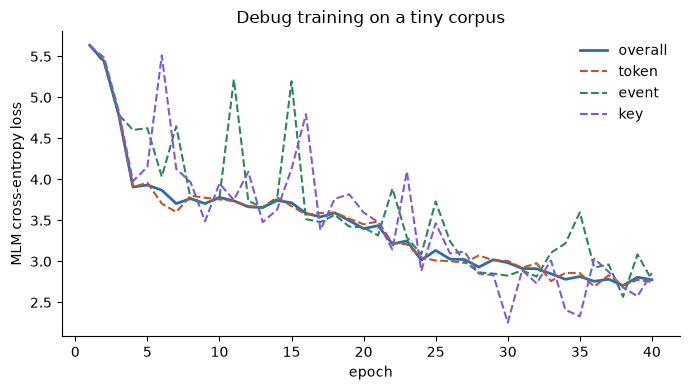

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
epochs = list(range(1, len(result.epoch_losses) + 1))
ax.plot(epochs, result.epoch_losses, color="#2b6cb0", linewidth=2, label="overall")

colors = {"token": "#c05621", "event": "#2f855a", "key": "#805ad5"}
for source, color in colors.items():
    values = [d.get(source) for d in result.epoch_losses_by_origin]
    xs = [e for e, v in zip(epochs, values, strict=True) if v is not None]
    ys = [v for v in values if v is not None]
    if ys:
        ax.plot(xs, ys, color=color, linewidth=1.5, linestyle="--", label=source)

ax.set_xlabel("epoch")
ax.set_ylabel("MLM cross-entropy loss")
ax.set_title("Debug training on a tiny corpus")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

In [6]:
assert result.epoch_losses[-1] < result.epoch_losses[0] * 0.7, "loss did not drop enough to call this an overfit"

first_seen = next(d for d in result.epoch_losses_by_origin if d)
last = result.epoch_losses_by_origin[-1]
for source in ("token", "event", "key"):
    print(f"{source}: {first_seen.get(source, float('nan')):.3f} -> {last.get(source, float('nan')):.3f}")
    assert last[source] < first_seen[source], f"'{source}' loss did not decrease"
print("all three masking-source losses decreased")

token: 5.636 -> 2.749
event: 5.635 -> 2.772
key: 5.629 -> 2.858
all three masking-source losses decreased


## Exit gate: destroyed context degrades predictions

**Methodology note:** the direct approach — corrupt the non-masked context tokens and check that loss goes *up* — is exactly what `shuffle_context_tokens` does below, but on a tiny, low-cardinality synthetic debug corpus this often barely moves the aggregate loss. That's not a bug: with only a handful of possible values per key and a handful of records, a per-key-marginal shortcut ("just guess this key's typical value") already explains most of the achievable loss reduction, so scrambling the rest of the context doesn't cost much in aggregate — this was confirmed by checking per-position loss deltas and per-field-type breakdowns while building this notebook, not assumed. The gradient-connectivity check right after it is the robust version: it confirms the *mechanism* genuinely depends on context (non-zero `d(loss)/d(context token embedding)`), which is true regardless of how numerically sensitive this particular fit's shortcut happens to be. See `plans/progress.md`'s Phase 6 entry.

In [7]:
planner = MaskingPlanner.from_registry(registry, processor.key_vocab, masking_config)
collator = PragmaCollator(masking_planner=planner)
batch = collator(tokenized)

model = result.model
model.eval()
with torch.no_grad():
    normal_out = model(batch)
    generator = torch.Generator().manual_seed(0)
    corrupted_batch = shuffle_context_tokens(batch, generator)
    corrupted_out = model(corrupted_batch)

print(f"normal loss:    {normal_out.loss.item():.4f}")
print(f"corrupted loss: {corrupted_out.loss.item():.4f}")

normal loss:    2.7634
corrupted loss: 2.7634


In [8]:
model.zero_grad()
report = context_dependency_grad(model, batch)
print(report)
assert report["any_nonzero"] is True, "predictions must structurally depend on context tokens"

{'n_context_ids_checked': 49, 'max_grad_norm': 1.037419080734253, 'any_nonzero': True}
